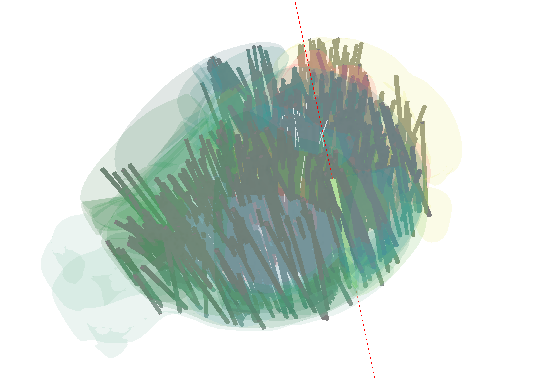

In [4]:
# Change kernel (on the right-top of Jupyter lab) to 'Python (ibl)'
# Alyx password for "intbrainlab" is: international

from pathlib import Path

from one.api import ONE

CACHE_DIR = Path('G:/academic/ONE')
CACHE_DIR.mkdir(parents=True, exist_ok=True)
one = ONE(base_url='https://openalyx.internationalbrainlab.org', cache_dir=CACHE_DIR, mode='remote')

eid0 = 'e5c75b62-6871-4135-b3d0-f6464c2d90c0'  # pid: aac3b928-e99a-4039-ace1-af45d0130d82
trials0 = one.load_object(eid0, 'trials', collection='alf', namespace='ibl')


E:\Anaconda\envs\ibl\Lib\site-packages\one\util.py:464: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


## Raw data check
The 	rials0 object loaded above is ALF behavioral data, not raw continuous ephys. The session may still contain raw SpikeGLX AP files under aw_ephys_data; the cell below checks for those files without downloading the large binaries.


In [5]:
from pathlib import PurePosixPath

datasets = one.list_datasets(eid0, details=True, query_type='remote', keep_eid_index=True)
rel = datasets['rel_path'].astype(str)

trials_rows = datasets.loc[rel.str.contains(r'(?:^|/)_(?:ibl_)?trials\.', regex=True), ['rel_path', 'file_size']].copy()
raw_ap_rows = datasets.loc[
    rel.str.contains(r'^raw_ephys_data/probe\d+/', regex=True)
    & rel.str.contains(r'\.ap\.(?:cbin|bin|meta|ch)$', regex=True),
    ['rel_path', 'file_size']
].copy()
raw_ap_rows['file_size_GB'] = raw_ap_rows['file_size'] / 1e9

CURRENT_OBJECT_IS_RAW = False
SESSION_HAS_RAW_AP = len(raw_ap_rows) > 0

print('trials0 type:', type(trials0))
print('Current loaded object is raw continuous ephys:', CURRENT_OBJECT_IS_RAW)
print('Session has raw AP files available:', SESSION_HAS_RAW_AP)
display(raw_ap_rows.sort_values('rel_path'))


trials0 type: <class 'one.alf.io.AlfBunch'>
Current loaded object is raw continuous ephys: False
Session has raw AP files available: True


rel_path  \
eid                                  id                                                                                        
e5c75b62-6871-4135-b3d0-f6464c2d90c0 4b5ce1cb-ff85-420b-b37a-b5624b484e87  raw_ephys_data/probe00/_spikeglx_ephysData_g0_...   
                                     3a92fd64-b9a6-443e-bce0-06e40084f8e9  raw_ephys_data/probe00/_spikeglx_ephysData_g0_...   
                                     abb0174e-5dd2-4b48-895b-bcbbaa8ce9e8  raw_ephys_data/probe00/_spikeglx_ephysData_g0_...   
                                     42848094-a332-4e3e-8d14-0d914bd6dc5d  raw_ephys_data/probe01/_spikeglx_ephysData_g0_...   
                                     fd15e4e8-4a81-4027-9928-1ccc71162034  raw_ephys_data/probe01/_spikeglx_ephysData_g0_...   
                                     cae304b0-b3f1-4407-8508-0f377347d567  raw_ephys_data/probe01/_spikeglx_ephysData_g0_...   

                                                                             file_size  \
eid                                  id                                                  
e5c75b62-6871-4135-b3d0-f6464c2d90c0 4b5ce1cb-ff85-420b-b37a-b5624b484e87  35529098643   
                                     3a92fd64-b9a6-443e-bce0-06e40084f8e9       137871   
                                     abb0174e-5dd2-4b48-895b-bcbbaa8ce9e8        17798   
                                     42848094-a332-4e3e-8d14-0d914bd6dc5d  39873075271   
                                     fd15e4e8-4a81-4027-9928-1ccc71162034       138018   
                                     cae304b0-b3f1-4407-8508-0f377347d567        17790   

                                                                           file_size_GB  
eid                                  id                                                  
e5c75b62-6871-4135-b3d0-f6464c2d90c0 4b5ce1cb-ff85-420b-b37a-b5624b484e87     35.529099  
                                     3a92fd64-b9a6-443e-bce0-06e40084f8e9      0.000138  
                                     abb0174e-5dd2-4b48-895b-bcbbaa8ce9e8      0.000018  
                                     42848094-a332-4e3e-8d14-0d914bd6dc5d     39.873075  
                                     fd15e4e8-4a81-4027-9928-1ccc71162034      0.000138  
                                     cae304b0-b3f1-4407-8508-0f377347d567      0.000018

## IBL kernel: optional raw AP download and conversion
Run this section in the Python (ibl) kernel. OpenAlyx provides AP raw data for this session as compressed SpikeGLX .ap.cbin files. Kilosort4 should be run on an int16 .ap.bin, so this section can download the .cbin/.meta/.ch files and decompress the selected probe. The default flags are False because each AP file is tens of GB and the decompressed .bin will require additional disk space.


In [7]:
from pathlib import Path, PurePosixPath
import json

PROBE = 'probe00'
RUN_RAW_DOWNLOAD = True
RUN_CBIN_DECOMPRESS = True

probe_rows = raw_ap_rows[raw_ap_rows['rel_path'].astype(str).str.contains(f'raw_ephys_data/{PROBE}/')].copy()
display(probe_rows.sort_values('rel_path'))

def expected_local_path(rel_path):
    """Return the normal ONE cache path for this relative dataset path."""
    rel_path = PurePosixPath(str(rel_path))
    hits = sorted(CACHE_DIR.glob(f'**/{rel_path.as_posix()}'))
    if hits:
        return hits[0]
    return CACHE_DIR / rel_path

def file_status(path, expected_size=None):
    path = Path(path)
    if not path.exists():
        return {'path': str(path), 'status': 'missing', 'size': 0, 'expected_size': expected_size}
    size = path.stat().st_size
    if expected_size and size == int(expected_size):
        status = 'complete'
    elif expected_size and size < int(expected_size):
        status = 'partial'
    elif expected_size and size > int(expected_size):
        status = 'size_mismatch_large'
    else:
        status = 'exists_unverified'
    return {'path': str(path), 'status': status, 'size': size, 'expected_size': expected_size}

def load_rel_path(eid, rel_path):
    rel_path = PurePosixPath(str(rel_path))
    return Path(one.load_dataset(
        eid,
        rel_path.name,
        collection=str(rel_path.parent),
        query_type='remote',
        download_only=True,
    ))

def ensure_dataset_downloaded(eid, row):
    rel_path = str(row['rel_path'])
    expected_size = int(row['file_size']) if row.get('file_size') else None
    target = expected_local_path(rel_path)
    before = file_status(target, expected_size)

    if before['status'] == 'complete':
        print('already complete:', target)
        return {**before, 'rel_path': rel_path, 'action': 'skipped_complete'}

    if before['status'] == 'partial':
        print('partial file found; continuing download/check:', target, before['size'], '/', expected_size)
    elif before['status'] == 'missing':
        print('missing file; starting download:', rel_path)
    else:
        print('existing file needs verification/redownload:', before)

    path = load_rel_path(eid, rel_path)
    after = file_status(path, expected_size)
    if after['status'] != 'complete':
        print('warning: file is still not complete after download attempt:', after)
    else:
        print('complete:', path)
    return {**after, 'rel_path': rel_path, 'action': 'downloaded_or_resumed', 'before': before}

download_records = []
downloaded_paths = []
if RUN_RAW_DOWNLOAD:
    needed_rows = probe_rows.sort_values('rel_path')
    if needed_rows.empty:
        raise RuntimeError(f'No AP raw files found for {PROBE}')
    for _, row in needed_rows.iterrows():
        record = ensure_dataset_downloaded(eid0, row)
        download_records.append(record)
        downloaded_paths.append(record['path'])
else:
    print('RUN_RAW_DOWNLOAD is False; raw AP files were not downloaded.')
    for _, row in probe_rows.sort_values('rel_path').iterrows():
        target = expected_local_path(row['rel_path'])
        download_records.append({**file_status(target, int(row['file_size'])), 'rel_path': str(row['rel_path']), 'action': 'checked_only'})

existing_cbin = sorted(CACHE_DIR.glob(f'**/raw_ephys_data/{PROBE}/*.ap.cbin'))
print('local .ap.cbin candidates:', existing_cbin)

ap_bin = None
decompress_record = {'action': 'not_requested', 'ap_bin': None}
if RUN_CBIN_DECOMPRESS:
    if not existing_cbin:
        raise FileNotFoundError('No local .ap.cbin found. Set RUN_RAW_DOWNLOAD=True first.')
    import spikeglx
    cbin = existing_cbin[0]
    reader = spikeglx.Reader(cbin)
    target_bin = cbin.with_suffix('.bin')
    expected_bin_size = int(reader.ns * reader.nc * reader.dtype.itemsize)
    before_bin = file_status(target_bin, expected_bin_size)

    if before_bin['status'] == 'complete':
        ap_bin = target_bin
        decompress_record = {**before_bin, 'action': 'skipped_complete'}
        print('decompressed AP bin already complete:', ap_bin)
    else:
        if before_bin['status'] == 'partial':
            print('partial decompressed .ap.bin found. mtscomp cannot append-resume decompression; overwriting this incomplete .bin:', before_bin)
        else:
            print('decompressing .ap.cbin to .ap.bin:', cbin)
        ap_bin = Path(reader.decompress_file(keep_original=True, out=target_bin, overwrite=True))
        after_bin = file_status(ap_bin, expected_bin_size)
        decompress_record = {**after_bin, 'action': 'decompressed_overwrite_if_needed', 'before': before_bin}
        if after_bin['status'] != 'complete':
            raise RuntimeError(f'Decompressed AP bin is not complete: {after_bin}')
        print('decompressed AP bin complete:', ap_bin)
else:
    print('RUN_CBIN_DECOMPRESS is False; no .ap.bin was created.')

manifest = {
    'eid': eid0,
    'probe': PROBE,
    'cache_dir': str(CACHE_DIR),
    'downloaded_paths': downloaded_paths,
    'download_records': download_records,
    'local_cbin_candidates': [str(p) for p in existing_cbin],
    'ap_bin': str(ap_bin) if ap_bin else None,
    'decompress_record': decompress_record,
}
manifest_path = Path('G:/academic/week8_raw_ap_manifest.json')
manifest_path.write_text(json.dumps(manifest, indent=2), encoding='utf-8')
print('manifest:', manifest_path)


rel_path  \
eid                                  id                                                                                        
e5c75b62-6871-4135-b3d0-f6464c2d90c0 4b5ce1cb-ff85-420b-b37a-b5624b484e87  raw_ephys_data/probe00/_spikeglx_ephysData_g0_...   
                                     3a92fd64-b9a6-443e-bce0-06e40084f8e9  raw_ephys_data/probe00/_spikeglx_ephysData_g0_...   
                                     abb0174e-5dd2-4b48-895b-bcbbaa8ce9e8  raw_ephys_data/probe00/_spikeglx_ephysData_g0_...   

                                                                             file_size  \
eid                                  id                                                  
e5c75b62-6871-4135-b3d0-f6464c2d90c0 4b5ce1cb-ff85-420b-b37a-b5624b484e87  35529098643   
                                     3a92fd64-b9a6-443e-bce0-06e40084f8e9       137871   
                                     abb0174e-5dd2-4b48-895b-bcbbaa8ce9e8        17798   

                                                                           file_size_GB  
eid                                  id                                                  
e5c75b62-6871-4135-b3d0-f6464c2d90c0 4b5ce1cb-ff85-420b-b37a-b5624b484e87     35.529099  
                                     3a92fd64-b9a6-443e-bce0-06e40084f8e9      0.000138  
                                     abb0174e-5dd2-4b48-895b-bcbbaa8ce9e8      0.000018

already complete: G:\academic\ONE\cortexlab\Subjects\KS043\2020-12-07\001\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.ap.cbin
already complete: G:\academic\ONE\cortexlab\Subjects\KS043\2020-12-07\001\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.ap.ch
already complete: G:\academic\ONE\cortexlab\Subjects\KS043\2020-12-07\001\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.ap.meta
local .ap.cbin candidates: [WindowsPath('G:/academic/ONE/cortexlab/Subjects/KS043/2020-12-07/001/raw_ephys_data/probe00/_spikeglx_ephysData_g0_t0.imec0.ap.cbin')]
partial decompressed .ap.bin found. mtscomp cannot append-resume decompression; overwriting this incomplete .bin: {'path': 'G:\\academic\\ONE\\cortexlab\\Subjects\\KS043\\2020-12-07\\001\\raw_ephys_data\\probe00\\_spikeglx_ephysData_g0_t0.imec0.ap.bin', 'status': 'partial', 'size': 51004800000, 'expected_size': 102897219040}



Decompressing: 100%|██████████| 372/372 [28:55<00:00,  4.66s/it]
INFO:mtscomp:Wrote G:\academic\ONE\cortexlab\Subjects\KS043\2020-12-07\001\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.ap.bin (95.8 GB).

Checking: 100%|██████████| 4455/4455 [1:34:19<00:00,  1.27s/it]


decompressed AP bin complete: G:\academic\ONE\cortexlab\Subjects\KS043\2020-12-07\001\raw_ephys_data\probe00\_spikeglx_ephysData_g0_t0.imec0.ap.bin
manifest: G:\academic\week8_raw_ap_manifest.json


## Kilosort4 kernel: run sorting on decompressed AP binary
After the .ap.bin exists, switch this notebook to the Kilosort4 kernel before running the cell below. The Kilosort4 environment does not include the IBL decompression stack, so only run this cell after the previous section has produced an int16 .ap.bin.


In [ ]:
from pathlib import Path

RUN_KILOSORT4 = True
PROBE = 'probe00'
ROOT = Path('G:/academic')
CACHE_DIR = ROOT / 'ONE'
RESULTS_DIR = ROOT / 'week8_kilosort4' / PROBE

ap_bin_candidates = sorted(CACHE_DIR.glob(f'**/raw_ephys_data/{PROBE}/*.ap.bin'))
print('AP bin candidates:', ap_bin_candidates)

if RUN_KILOSORT4:
    if not ap_bin_candidates:
        raise FileNotFoundError('No decompressed .ap.bin found. Run the IBL-kernel download/decompress cell first.')

    AP_BIN = ap_bin_candidates[0]
    settings = {
        'filename': AP_BIN,
        'n_chan_bin': 385,
        'fs': 30000,
    }

    from kilosort import run_kilosort
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    ks_output = run_kilosort(
        settings=settings,
        probe_name='NeuroPix1_default.mat',
        results_dir=RESULTS_DIR,
        data_dtype='int16',
        save_extra_vars=True,
        verbose_console=True,
    )
    print('Kilosort4 output directory:', RESULTS_DIR)
else:
    if ap_bin_candidates:
        print('RUN_KILOSORT4 is False; set it to True to run Kilosort4 on:', ap_bin_candidates[0])
    else:
        print('RUN_KILOSORT4 is False and no .ap.bin is present yet. Decompress the selected .ap.cbin in the IBL kernel first.')


AP bin candidates: [WindowsPath('G:/academic/ONE/cortexlab/Subjects/KS043/2020-12-07/001/raw_ephys_data/probe00/_spikeglx_ephysData_g0_t0.imec0.ap.bin')]


2026-06-29 19:54:45,086 kilosort.run_kilosort INFO     Kilosort version 4.1.7
2026-06-29 19:54:45,099 kilosort.run_kilosort INFO     Python version 3.11.15
2026-06-29 19:54:45,107 kilosort.run_kilosort INFO     ----------------------------------------
2026-06-29 19:54:45,109 kilosort.run_kilosort INFO     System information:
2026-06-29 19:54:45,111 kilosort.run_kilosort INFO     Windows-10-10.0.26200-SP0 AMD64
2026-06-29 19:54:45,113 kilosort.run_kilosort INFO     Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
2026-06-29 19:54:47,113 kilosort.run_kilosort INFO     Using GPU for PyTorch computations. Specify `device` to change this.
2026-06-29 19:54:47,123 kilosort.run_kilosort INFO     Using CUDA device: NVIDIA GeForce RTX 2050 4.00GB
2026-06-29 19:54:47,130 kilosort.run_kilosort INFO     ----------------------------------------
2026-06-29 19:54:47,132 kilosort.run_kilosort INFO     Sorting [WindowsPath('G:/academic/ONE/cortexlab/Subjects/KS043/2020-12-07/001/raw_ephys_data/probe0